In [1]:
import pprint # Pretty print data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # statistical visualisation

#### Import dataset `bg_id.csv`
Target variables
- **bg_hse06:** Band gap calculated with HSE06 hybrid functional
- **bg_pbesol:** Band gap calculated with PBEsol GGA functional

Features
- **r_s:** Wigner-Seitz radius?
- **r_val:** Valence radius
- **r_cov:** Covalent radius
- **e_H:** HOMO Energy
- **e_L:** LUMO Energy
- **AN:** Atomic number
- **IP:** Ionisation potential
- **EA:** Electron affinity
- **EN:** Electronegativity
- **N_val:** Valence electrons
- **N_unf:** Unfilled electrons
- **CE:** Cohesive energy per atom

In [2]:
df = pd.read_csv('bg_id.csv')
df.head()

,material,formula,bg_hse06 (eV),bg_pbesol (eV),r_s (AA),r_val (AA),e_H (eV),e_L (eV),AN,EA (eV),IP (eV),r_cov (AA),EN (Pauling),N_val,N_unf,CE (eV/atom)
0,Cs10Ga9H25,Cs20Ga18H50,3.772085,2.908479,1.076200,1.149836,-7.334358,0.187133,19.409091,-0.311234,9.787071,0.980227,1.799773,3.454545,1.818182,-3.739167
1,MgSeO3,Mg4O12Se4,5.408899,3.944471,0.705770,0.717850,-9.990844,2.950408,14.000000,-1.194358,10.812404,0.918000,2.836000,7.200000,1.600000,-4.539193
2,La2(GeO3)3,La4Ge6O18,4.823150,3.175656,0.783279,0.697779,-10.877810,1.404834,20.142857,-1.250617,10.545294,0.977143,2.799286,7.285714,3.428571,-4.179108
3,YFe2,Fe4Y2,0.033774,0.015584,1.433750,0.569750,-4.799730,-1.045520,30.333333,1.093334,7.063045,1.513333,1.626667,6.333333,5.666667,-9.910190
4,Y6O4F9,Y24F36O16,1.875181,1.000005,0.850771,0.568908,-10.533281,1.281480,18.263158,-2.320959,12.840382,1.008947,2.994737,5.526316,3.736842,-4.820730


In [3]:
df.describe()

,bg_hse06 (eV),bg_pbesol (eV),r_s (AA),r_val (AA),e_H (eV),e_L (eV),AN,EA (eV),IP (eV),r_cov (AA),EN (Pauling),N_val,N_unf,CE (eV/atom)
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,3.200890,1.959963,0.931818,0.807588,-8.769346,1.037962,20.182912,-0.993152,10.155826,1.072735,2.476240,6.609825,2.799051,-6.122596
std,2.240508,1.757500,0.279892,0.276092,1.903806,1.690161,10.686835,0.880000,1.901849,0.269911,0.507032,2.876479,1.447102,3.406027
min,0.000003,0.000110,0.463150,0.375925,-13.362068,-3.166943,1.333333,-4.705495,4.950872,0.382222,1.184103,1.000000,0.000000,-20.798700
25%,1.403948,0.278713,0.716384,0.601452,-10.173156,0.375336,12.909091,-1.295210,9.009644,0.892878,2.051864,4.762500,1.777778,-8.152651
50%,3.249741,1.710395,0.868521,0.750888,-9.179417,1.326546,18.000000,-0.956222,10.336332,1.025714,2.611818,6.000000,2.458042,-5.895364
75%,4.802854,3.235631,1.119327,0.953954,-7.437929,1.955399,24.780303,-0.546783,11.177850,1.240000,2.849821,8.000000,3.333333,-3.731181
max,10.353938,7.956517,2.015117,2.089317,-3.526817,5.830865,67.250000,1.468583,16.605751,2.090000,3.775000,18.000000,7.666667,0.000000


In [4]:
# Get the list of feature columns
blacklist = ['bg_hse06 (eV)','bg_pbesol (eV)','formula','material']
feature_cols = [col for col in list(df.columns) if col not in blacklist]

# Get array of features
x = df[feature_cols].values

# Get array of target variables
y_1 = df['bg_hse06 (eV)']
y_2 = df['bg_pbesol (eV)']

print(f'shape of x: {x.shape}')
print(f'shape of y(hse06): {y_1.shape}')
print(f'shape of y(pbesol): {y_2.shape}')

shape of x: (950, 12)
shape of y(hse06): (950,)
shape of y(pbesol): (950,)


In [5]:
from sklearn import metrics
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import learning_curve

def make_prediction_plot(x, y, y_pred, model):
    '''
    Plot predictions for the given model and data.

    Parameters:
    x : Input features.
    y : Actual target values.
    y_pred: Predicted values.
    model: Fitted model.
    '''
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.scatter(y, y_pred, c=y, cmap='viridis')
    ax.plot(y, y, 'r-')
    ax.set_xlabel(f'true {y.name}')
    ax.set_ylabel(f'predicted {y.name}')
    ax.set_title(f'{y.name} {model.__class__.__name__} prediction plot')
    plt.show()
    print('Training scores:')
    print (f'MAE = {metrics.mean_absolute_error(y,y_pred):.3f}')
    print(f'RMSE = {metrics.root_mean_squared_error(y,y_pred):.3f}')
    print(f'r^2 = {model.score(x,y):.3f}')

def print_cross_val(x, y, model, n_splits=10, random_state=42):
    '''
    Print cross validation scores for the given model and data.

    Parameters:
    x : Input features.
    y : Actual target values.
    model: Fitted model.
    n_splits: number of cv splits.
    random_state: random state.
    '''
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scoring_metrics = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
    }
    results = cross_validate(model, x, y, cv=cv, scoring=scoring_metrics)
    
    print('Cross-validation scores:')
    print(f'Mean MAE = {np.mean(np.abs(results['test_mae'])):.3f}')
    print(f'Mean RMSE = {np.mean(np.abs(results['test_rmse'])):.3f}')
    print(f'Mean r^2 = {np.mean(results['test_r2']):.3f}')

def make_learning_curve_plot(x, y, model):
    '''
    Plot 'r2' traininlearning curve for given model and data.

    Parameters:
    x : Input features.
    y : Actual target values.
    model: Fitted model.
    '''
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=x,
        y=y,
        train_sizes=np.arange(0.1, 1.0, 0.1),    # [0.1, 0.2, 0.3, ..., 0.9]
        cv=10,                                   # 10-fold cross-validation
        scoring="r2",                            # or "r2", "neg_mean_absolute_error", etc.
        n_jobs=-1,
        shuffle=True,
        random_state=42,
    )
    
    train_sizes_pct = np.arange(0.1, 1.0, 0.1)
    train_scores_mean = train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    test_scores_mean = test_scores.mean(axis=1)
    test_scores_std = test_scores.std(axis=1)
    
    # Plot
    fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.errorbar(
        train_sizes_pct, train_scores_mean,
        yerr=train_scores_std,
        fmt="o-", color="steelblue", capsize=4, label="Training r^2"
    )
    
    ax.errorbar(
        train_sizes_pct, test_scores_mean,
        yerr=test_scores_std,
        fmt="o-", color="tomato", capsize=4, label="Test r^2"
    )
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("r^2")
    ax.set_title(f'{y.name} {model.__class__.__name__} learning curve')
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

### Data preprocessing

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression

# Impute & Scale
imputer = SimpleImputer(strategy="mean")
x = imputer.fit_transform(x)

scaler = StandardScaler()
x = scaler.fit_transform(x)

# Feature Selection
# k_1=10
# selector_1 = SelectKBest(score_func=f_regression, k=k_1)
# x_1 = selector_1.fit_transform(x, y_1)

# k_2=10
# selector_2 = SelectKBest(score_func=f_regression, k=k_2)
# x_2 = selector_2.fit_transform(x, y_2)

In [7]:
# Import models
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ripbesole import KernelRipbesole
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

### Random Forest

#### hse06


In [8]:
rf_1 = RandomForestRegressor(
    n_estimators=500,
    criterion='squared_error', 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features=0.8,
    n_jobs=-1
)
rf_1.fit(x,y_1)
y_1_rf = rf_1.predict(x)

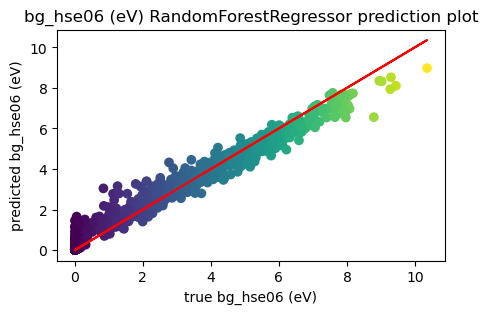

Training scores:
MAE = 0.324
RMSE = 0.456
r^2 = 0.958


In [9]:
make_prediction_plot(x, y_1, y_1_rf, rf_1)

In [10]:
print_cross_val(x, y_1, rf_1)

Cross-validation scores:
Mean MAE = 0.885
Mean RMSE = 1.239
Mean r^2 = 0.681


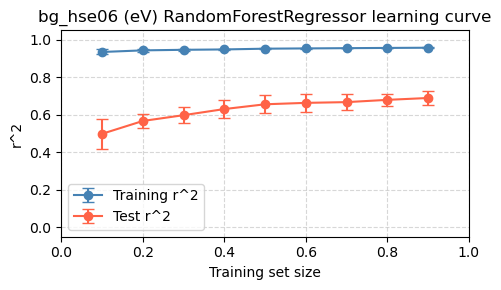

In [11]:
make_learning_curve_plot(x, y_1, rf_1)

#### pbesol

In [12]:
rf_2 = RandomForestRegressor(
    n_estimators=500,
    criterion='squared_error', 
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1,
    max_features=0.8,
    n_jobs=-1
)
rf_2.fit(x,y_2)
y_2_rf = rf_2.predict(x)

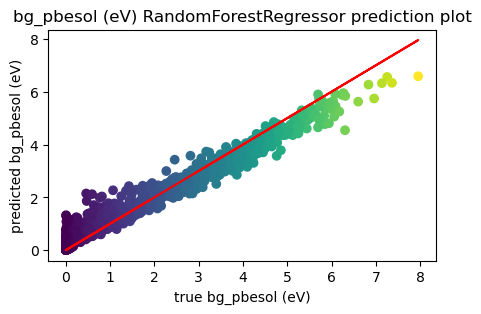

Training scores:
MAE = 0.281
RMSE = 0.389
r^2 = 0.951


In [13]:
make_prediction_plot(x, y_2, y_2_rf, rf_2)

In [14]:
print_cross_val(x, y_2, rf_2)

Cross-validation scores:
Mean MAE = 0.770
Mean RMSE = 1.071
Mean r^2 = 0.612


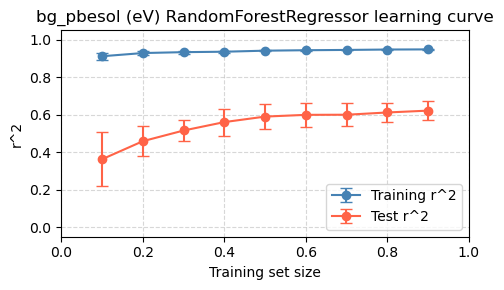

In [15]:
make_learning_curve_plot(x, y_2, rf_2)

### Kernel Ridge

#### hse06

In [17]:
kr_1 = KernelRidge(
    alpha=0.1,
    gamma=0.1,
    kernel='laplacian',
)
kr_1.fit(x,y_1)
y_1_kr = kr_1.predict(x)

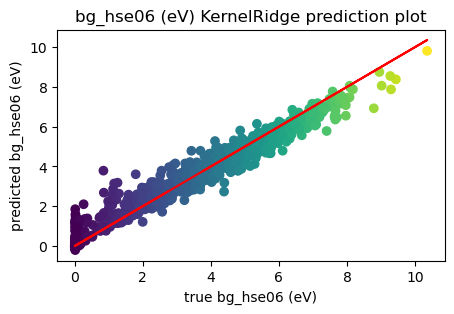

Training scores:
MAE = 0.336
RMSE = 0.488
r^2 = 0.953


In [18]:
make_prediction_plot(x, y_1, y_1_kr, kr_1)

In [19]:
print_cross_val(x, y_1, kr_1)

Cross-validation scores:
Mean MAE = 0.837
Mean RMSE = 1.176
Mean r^2 = 0.713


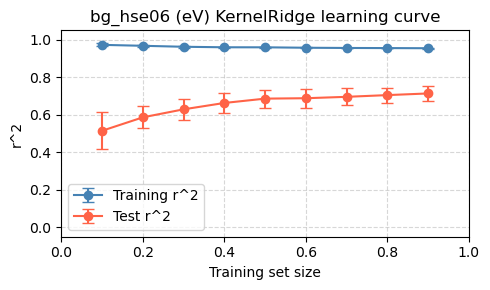

In [20]:
make_learning_curve_plot(x, y_1, kr_1)

#### pbesol

In [21]:
kr_2 = KernelRidge(
    alpha=0.1,
    gamma=0.1,
    kernel='laplacian',
)
kr_2.fit(x,y_2)
y_2_kr = kr_2.predict(x)

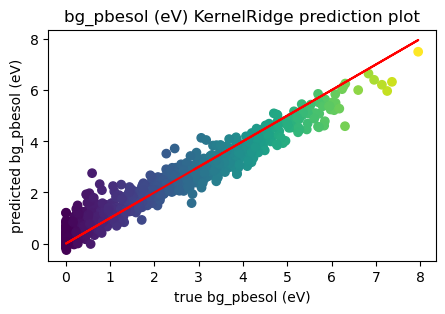

Training scores:
MAE = 0.289
RMSE = 0.412
r^2 = 0.945


In [22]:
make_prediction_plot(x, y_2, y_2_kr, kr_2)

In [23]:
print_cross_val(x, y_2, kr_2)

Cross-validation scores:
Mean MAE = 0.719
Mean RMSE = 0.997
Mean r^2 = 0.665


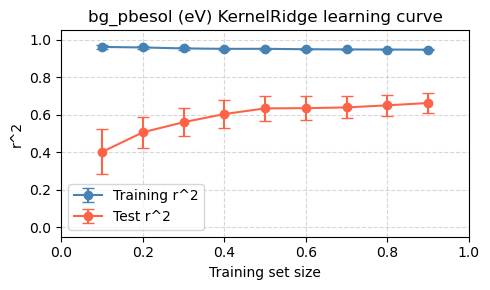

In [24]:
make_learning_curve_plot(x, y_2, kr_2)

### XGBoost

#### hse06

In [25]:
xgb_1 = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=5,
    n_estimators=500,
    reg_alpha=5.0,
    reg_lambda=1.0,
    subsample=0.6,
)
xgb_1.fit(x,y_1)
y_1_xgb = xgb_1.predict(x)

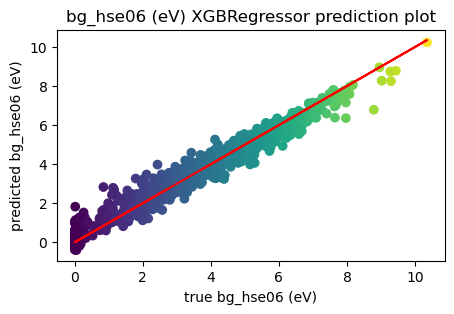

Training scores:
MAE = 0.313
RMSE = 0.430
r^2 = 0.963


In [26]:
make_prediction_plot(x, y_1, y_1_xgb, xgb_1)

In [27]:
print_cross_val(x, y_1, xgb_1)

Cross-validation scores:
Mean MAE = 0.847
Mean RMSE = 1.181
Mean r^2 = 0.709


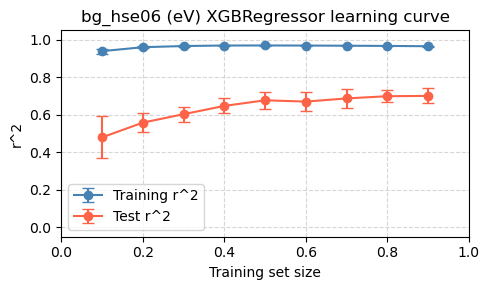

In [28]:
make_learning_curve_plot(x, y_1, xgb_1)

#### pbesol

In [29]:
xgb_2 = XGBRegressor(
    booster='gbtree',
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=5,
    n_estimators=500,
    reg_alpha=5.0,
    reg_lambda=1.0,
    subsample=0.6,
)
xgb_2.fit(x,y_2)
y_2_xgb = xgb_2.predict(x)

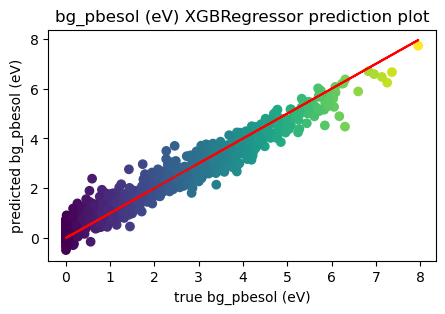

Training scores:
MAE = 0.286
RMSE = 0.389
r^2 = 0.951


In [30]:
make_prediction_plot(x, y_2, y_2_xgb, xgb_2)

In [31]:
print_cross_val(x, y_2, xgb_2)

Cross-validation scores:
Mean MAE = 0.725
Mean RMSE = 1.000
Mean r^2 = 0.661


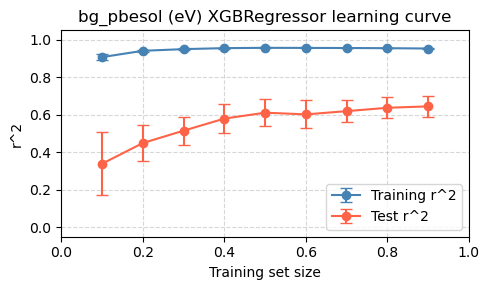

In [32]:
make_learning_curve_plot(x, y_2, xgb_2)

### Violins plots

In [33]:
# Define models
models = [
    rf_1,
    kr_1,
    xgb_1,
]

# Run CV for each model
records = []
for model in models:
    scores = cross_val_score(
        estimator=model,
        X=x,
        y=y_1,
        cv=10,
        scoring='r2',
        n_jobs=-1,
    )
    for score in scores:
        records.append({'Model': model.__class__.__name__, 'r^2': score})

df_plot_1 = pd.DataFrame(records) # Make dataframe from CV scores

In [34]:
# Define models
models = [
    rf_2,
    kr_2,
    xgb_2,
]

# Run CV for each model
records = []
for model in models:
    scores = cross_val_score(
        estimator=model,
        X=x,
        y=y_2,
        cv=10,
        scoring='r2',
        n_jobs=-1,
    )
    for score in scores:
        records.append({'Model': model.__class__.__name__, 'r^2': score})

df_plot_2 = pd.DataFrame(records) # Make dataframe from CV scores

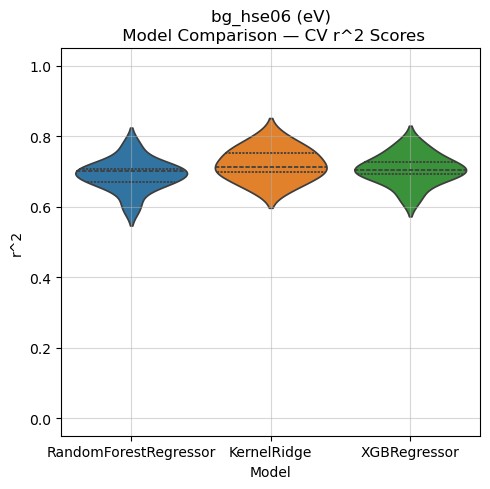

In [35]:
# Plot
fig, ax = plt.subplots(figsize=(5, 5))

sns.violinplot(
    data=df_plot_1,
    y='r^2',
    x='Model',
    hue='Model',
    inner='quartile',
    legend=False,
    ax=ax,
)

ax.set_title(f'{y_1.name}\n Model Comparison — CV r^2 Scores')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

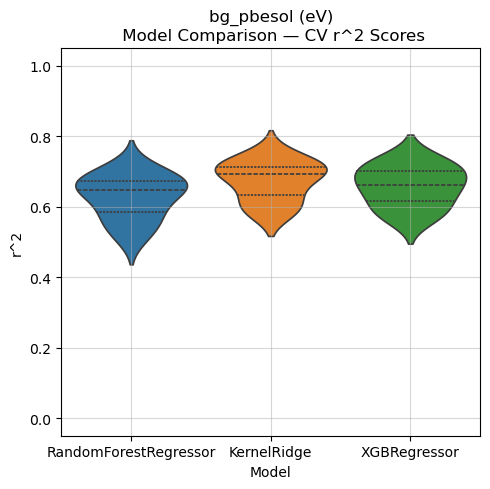

In [37]:
# Plot
fig, ax = plt.subplots(figsize=(5, 5))

sns.violinplot(
    data=df_plot_2,
    y='r^2',
    x='Model',
    hue='Model',
    inner='quartile',
    legend=False,
    ax=ax,
)

ax.set_title(f'{y_2.name}\n Model Comparison — CV r^2 Scores')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()